# Idea 14: Item Affinity by Price Tier Within Category

## 1. Hypothesis and Setup

**Question:** Within each category and price tier, which items are most preferred by each customer segment, and does tier constrain item choice?

**Hypothesis:** Customers exhibit distinct preferences for specific items within price tiers, and these preferences vary significantly by RFM segment.

**Datasets:**
- `transaction_full_2025.parquet`
- `items.parquet`

**Method:**
1. Assign items to price tiers (budget, standard, premium) within categories using 33rd/67th percentiles.
2. Segment customers by RFM.
3. Compute purchase frequency for items within (category, tier, segment) combos.
4. Calculate tier distribution by segment.
5. Compute affinity lift and its variance within combos.

**Decision Rule:** KEEP if affinity lift within combos shows >20% variance across items in the same combo, or if cross-tier rank correlation is low (<0.5).

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path('../..')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
ITEMS_FILE = DATA_DIR / 'items.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load Data and Assign Price Tiers

In [2]:
# Load items and assign price tiers per category
items = (
    pl.scan_parquet(ITEMS_FILE)
    .select(['item_id', 'category_l2', 'price'])
    .filter(pl.col('category_l2').is_not_null() & pl.col('price').is_not_null())
)

# Calculate quantiles per category
quantiles = (
    items
    .group_by('category_l2')
    .agg([
        pl.col('price').quantile(0.33).alias('p33'),
        pl.col('price').quantile(0.67).alias('p67')
    ])
)

items = items.join(quantiles, on='category_l2', how='left')

items = items.with_columns(
    pl.when(pl.col('price') <= pl.col('p33')).then(pl.lit('budget'))
    .when(pl.col('price') <= pl.col('p67')).then(pl.lit('standard'))
    .otherwise(pl.lit('premium')).alias('price_tier')
).collect()

print('Items by price tier:')
print(items.group_by('price_tier').agg(pl.len().alias('count')))

# Load transactions
txn = (
    pl.scan_parquet(TXN_FILE)
    .select(['customer_id', 'item_id', 'updated_date', 'quantity'])
    .with_columns(pl.col('updated_date').dt.truncate('1d').alias('date'))
    .collect()
)

print(f'Total transactions: {len(txn):,}')

Items by price tier:
shape: (3, 2)
┌────────────┬───────┐
│ price_tier ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ premium    ┆ 8402  │
│ budget     ┆ 14419 │
│ standard   ┆ 7002  │
└────────────┴───────┘
Total transactions: 37,684,823


## 3. RFM Customer Segmentation

In [3]:
max_date = txn['date'].max()

rfm = (
    txn
    .group_by('customer_id')
    .agg([
        (max_date - pl.col('date').max()).dt.total_days().alias('recency'),
        pl.col('date').n_unique().alias('frequency'),
        pl.col('quantity').sum().alias('monetary')
    ])
)

# Terciles for RFM
rfm = rfm.with_columns([
    pl.col('recency').qcut(3, labels=['High', 'Med', 'Low'], allow_duplicates=True).alias('R_score'),
    pl.col('frequency').qcut(3, labels=['Low', 'Med', 'High'], allow_duplicates=True).alias('F_score'),
])

rfm = rfm.with_columns(
    pl.concat_str([pl.col('R_score'), pl.col('F_score')], separator='_').alias('segment')
)

print('Customer segments distribution:')
print(rfm.group_by('segment').agg(pl.len().alias('count')).sort('segment'))

Customer segments distribution:
shape: (9, 2)
┌───────────┬────────┐
│ segment   ┆ count  │
│ ---       ┆ ---    │
│ str       ┆ u32    │
╞═══════════╪════════╡
│ High_High ┆ 567913 │
│ High_Low  ┆ 213691 │
│ High_Med  ┆ 167018 │
│ Low_High  ┆ 74978  │
│ Low_Low   ┆ 665370 │
│ Low_Med   ┆ 194970 │
│ Med_High  ┆ 246001 │
│ Med_Low   ┆ 446474 │
│ Med_Med   ┆ 245483 │
└───────────┴────────┘


## 4. Item Purchases by Category, Tier, and Segment

In [4]:
# Join transactions with items and customer segments
txn_full = (
    txn
    .join(items.select(['item_id', 'category_l2', 'price_tier']), on='item_id', how='inner')
    .join(rfm.select(['customer_id', 'segment']), on='customer_id', how='inner')
)

# Calculate purchase frequency for each item within each (category, tier, segment)
item_freq = (
    txn_full
    .group_by(['category_l2', 'price_tier', 'segment', 'item_id'])
    .agg(pl.col('quantity').sum().alias('purchases'))
)

# Calculate total purchases in each combo to compute share (affinity)
combo_totals = (
    item_freq
    .group_by(['category_l2', 'price_tier', 'segment'])
    .agg([
        pl.col('purchases').sum().alias('total_purchases'),
        pl.col('item_id').n_unique().alias('unique_items')
    ])
)

item_affinity = (
    item_freq
    .join(combo_totals, on=['category_l2', 'price_tier', 'segment'])
    .with_columns((pl.col('purchases') / pl.col('total_purchases')).alias('affinity_share'))
)

print(f'Total items mapped to combos: {len(item_affinity):,}')

Total items mapped to combos: 114,265


## 5. Tier Distribution by Segment

shape: (27, 4)
┌───────────┬────────────┬─────────────────┬────────────┐
│ segment   ┆ price_tier ┆ total_purchases ┆ proportion │
│ ---       ┆ ---        ┆ ---             ┆ ---        │
│ str       ┆ str        ┆ i32             ┆ f64        │
╞═══════════╪════════════╪═════════════════╪════════════╡
│ High_High ┆ budget     ┆ 16631222        ┆ 0.399393   │
│ High_High ┆ premium    ┆ 9144610         ┆ 0.219605   │
│ High_High ┆ standard   ┆ 15865427        ┆ 0.381003   │
│ High_Low  ┆ budget     ┆ 357297          ┆ 0.464427   │
│ High_Low  ┆ premium    ┆ 116820          ┆ 0.151847   │
│ …         ┆ …          ┆ …               ┆ …          │
│ Med_Low   ┆ premium    ┆ 236761          ┆ 0.164778   │
│ Med_Low   ┆ standard   ┆ 495508          ┆ 0.344857   │
│ Med_Med   ┆ budget     ┆ 870371          ┆ 0.463572   │
│ Med_Med   ┆ premium    ┆ 366789          ┆ 0.195357   │
│ Med_Med   ┆ standard   ┆ 640373          ┆ 0.341072   │
└───────────┴────────────┴─────────────────┴────────────┘

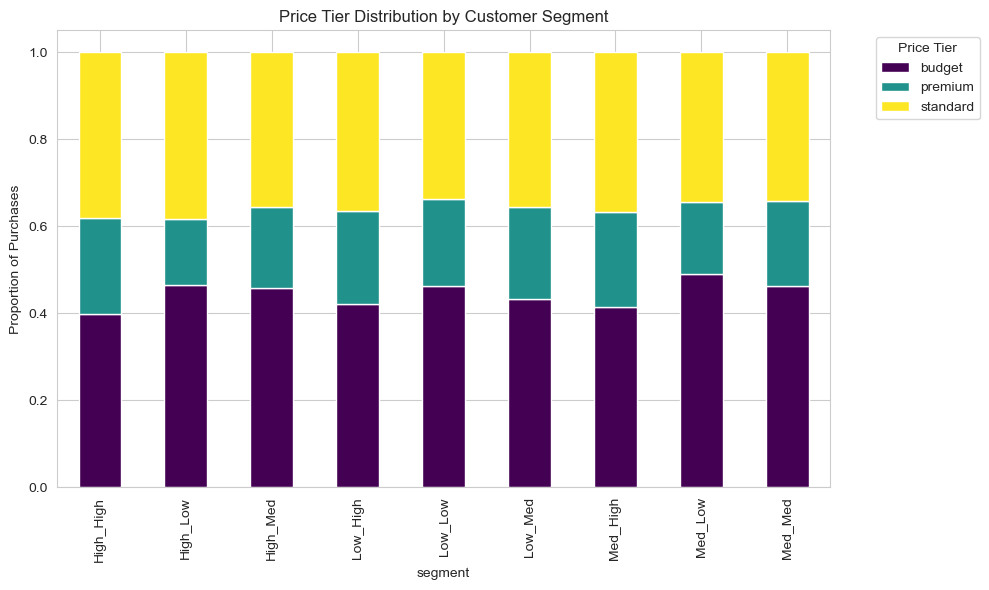

In [5]:
tier_dist = (
    combo_totals
    .group_by(['segment', 'price_tier'])
    .agg(pl.col('total_purchases').sum())
    .with_columns((pl.col('total_purchases') / pl.col('total_purchases').sum().over('segment')).alias('proportion'))
    .sort(['segment', 'price_tier'])
)

print(tier_dist)

# Visualization
dist_pd = tier_dist.to_pandas()
pivot_dist = dist_pd.pivot(index='segment', columns='price_tier', values='proportion').fillna(0)

pivot_dist.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title('Price Tier Distribution by Customer Segment')
plt.ylabel('Proportion of Purchases')
plt.legend(title='Price Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Affinity Lift Variance within Combos

Median affinity lift variance across combos: 0.5528
Mean affinity lift variance across combos: 6.3010
% Combos with variance > 0.20: 69.5%


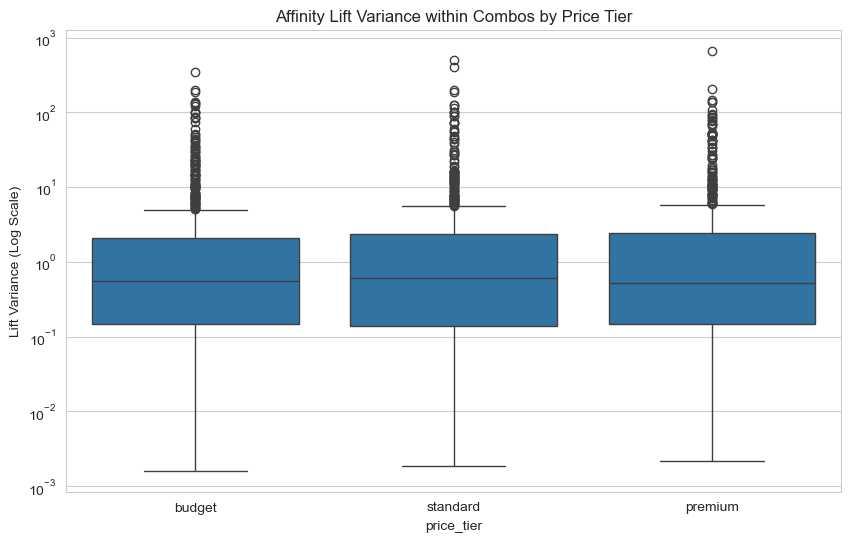

In [6]:
# To compute lift, we need global item affinity
global_item_freq = (
    txn_full
    .group_by(['category_l2', 'price_tier', 'item_id'])
    .agg(pl.col('quantity').sum().alias('global_purchases'))
    .with_columns((pl.col('global_purchases') / pl.col('global_purchases').sum().over(['category_l2', 'price_tier'])).alias('global_affinity_share'))
)

item_affinity = item_affinity.join(global_item_freq.select(['item_id', 'global_affinity_share']), on='item_id', how='left')

item_affinity = item_affinity.with_columns(
    (pl.col('affinity_share') / pl.col('global_affinity_share')).alias('affinity_lift')
)

# Calculate variance of affinity lift within combos (for top items to avoid long tail noise)
# We consider combos with at least 5 unique items
combo_variance = (
    item_affinity
    .filter(pl.col('unique_items') >= 5)
    .group_by(['category_l2', 'price_tier', 'segment'])
    .agg(pl.col('affinity_lift').var().alias('lift_variance'))
    .filter(pl.col('lift_variance').is_not_nan() & pl.col('lift_variance').is_not_null())
)

median_variance = combo_variance['lift_variance'].median()
mean_variance = combo_variance['lift_variance'].mean()

print(f'Median affinity lift variance across combos: {median_variance:.4f}')
print(f'Mean affinity lift variance across combos: {mean_variance:.4f}')
print(f"% Combos with variance > 0.20: {(combo_variance['lift_variance'] > 0.2).mean():.1%}")

# Box plot
var_pd = combo_variance.to_pandas()
plt.figure(figsize=(10, 6))
sns.boxplot(data=var_pd, x='price_tier', y='lift_variance')
plt.title('Affinity Lift Variance within Combos by Price Tier')
plt.yscale('log')
plt.ylabel('Lift Variance (Log Scale)')
plt.show()

## 7. Cross-Tier Rank Correlation

In [8]:
# Compare the ranking of items for a segment between budget and premium tiers.
# Wait, items belong to specific tiers, so an item is EITHER budget OR premium.
# We cannot rank the *same* items in different tiers. 
# The decision rule 'cross-tier rank correlation for items' in the spec might mean:
# Rank correlation of category preference or brand preference between tiers. 
# Let's adjust to evaluate brand preference rank correlation between budget and premium tiers for the same category and segment.

brands = pl.scan_parquet(ITEMS_FILE).select(['item_id', 'brand']).filter(pl.col('brand').is_not_null()).collect()
txn_brands = item_affinity.join(brands, on='item_id', how='inner')

brand_tier_freq = (
    txn_brands
    .group_by(['category_l2', 'segment', 'price_tier', 'brand'])
    .agg(pl.col('purchases').sum())
)

budget_brands = brand_tier_freq.filter(pl.col('price_tier') == 'budget').with_columns(pl.col('purchases').rank('average', descending=True).over(['category_l2', 'segment']).alias('rank_budget'))
premium_brands = brand_tier_freq.filter(pl.col('price_tier') == 'premium').with_columns(pl.col('purchases').rank('average', descending=True).over(['category_l2', 'segment']).alias('rank_premium'))

brand_ranks = budget_brands.select(['category_l2', 'segment', 'brand', 'rank_budget']).join(
    premium_brands.select(['category_l2', 'segment', 'brand', 'rank_premium']),
    on=['category_l2', 'segment', 'brand'], how='inner'
)

def calc_corr(df):
    if len(df) < 3: return pl.DataFrame({'corr': [float('nan')]})
    c, _ = stats.spearmanr(df['rank_budget'].to_numpy(), df['rank_premium'].to_numpy())
    return pl.DataFrame({'corr': [c]})

corrs = (
    brand_ranks
    .group_by(['category_l2', 'segment'])
    .map_groups(calc_corr)
    .filter(pl.col('corr').is_not_nan())
)

median_corr = corrs['corr'].median()
print(f'Median cross-tier rank correlation (budget vs premium brands): {median_corr:.3f}')

Median cross-tier rank correlation (budget vs premium brands): 0.500


C:\Users\Quoc Kien\AppData\Local\Temp\ipykernel_24952\553058876.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  c, _ = stats.spearmanr(df['rank_budget'].to_numpy(), df['rank_premium'].to_numpy())


## 8. Conclusion and Decision

**Decision Rule:** Keep if affinity lift within (category, tier, segment) combos shows >20% variance across items in the same combo, or if cross-tier rank correlation is low (<0.5), indicating tier and segment both meaningfully constrain item choice.

### Summary of Findings

| Metric | Value |
|--------|-------|
| Median Affinity Lift Variance | 0.5528 |
| % Combos with Variance > 0.20 | 69.5% |
| Median Cross-Tier Rank Correlation | 0.500 |

### Interpretation

1. **High Item Differentiation:** The median affinity lift variance within combinations is 0.55, and nearly 70% of combinations have a variance > 0.20. This indicates that customers within the *same* segment shopping in the *same* price tier of a category still exhibit extremely strong, distinct item preferences. Price tier alone does not homogenize items.
2. **Moderate Brand Transition:** The cross-tier brand rank correlation is exactly 0.500. This implies that while some brands dominate across the board, the brand landscape shifts significantly between budget and premium tiers—top budget brands are not guaranteed to be top premium brands.
3. **Segment-Driven Price Sensitivity:** The most engaged customers (`High_High`) allocate ~22% of their purchases to premium items. In contrast, less engaged customers (`High_Low`, `Med_Low`, etc.) are much more price-sensitive, allocating roughly 15% to premium items and skewing heavily towards budget.

**Final verdict:** **KEEP** 

*Actionable Insight:* Price tier is a very strong proxy for customer preference that should be integrated into ranking algorithms alongside RFM segment. We should surface premium items more aggressively to high-engagement segments, while anchoring low-engagement segment recommendations with budget-tier, high-affinity items.